In [62]:
import pandas as pd
import numpy as np
import matplotlib as mlt

df = pd.read_csv('superstore.csv')
# print(df.head())
# print(df.tail)
# print(df.shape)
# print(df.columns)
# print(df.info)
# print(df.describe)
# print(df.isnull().sum())
# print(df.duplicated().sum())
# print(df.dtypes)
# print(df.columns.tolist())
# print(df['Order Date'].head())

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d-%m-%Y'
)
# print(df.info())
# Order Year

df['Order Year'] = df['Order Date'].dt.year

# Order Month
df['Order Month'] = df['Order Date'].dt.month_name()

# Order Quarter
df['Order Quarter'] = df['Order Date'].dt.quarter

#Total Sales
print('Total Sales:',df['Sales'].sum())
#Total Profit
print('Total Profit:',df['Profit'].sum())
#Total Orders
print("Total Orders:", df.shape[0])
#Average order value
print('Average Order Value',round(df['Sales'].mean(),2))

#Sales By category
sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_category)

#Profit By Category
profit_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(profit_category)

#Sales By region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

#Profit By Region
profit_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(profit_region)

#Sales By Segment
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print(segment_sales)

#Top 10 Customers
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

#Top 10 Products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)


Total Sales: 2326534.3543
Total Profit: 292296.81460000004
Total Orders: 10194
Average Order Value 228.23
Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64
Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64
Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64
Region
West       110798.8170
East        94883.2603
South       46749.4303
Central     39865.3070
Name: Profit, dtype: float64
Segment
Consumer       1.170660e+06
Corporate      7.158061e+05
Home Office    4.400684e+05
Name: Sales, dtype: float64
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez        

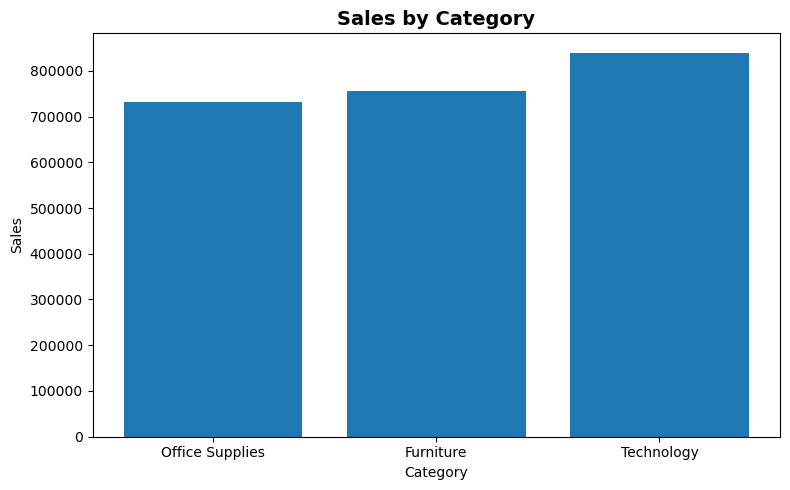

In [44]:
# Visualisation
import matplotlib.pyplot as plt

sales_category = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))
plt.bar(sales_category.index, sales_category.values)

plt.title("Sales by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("Images/Sales_by_Category.png", dpi=300)
plt.show()

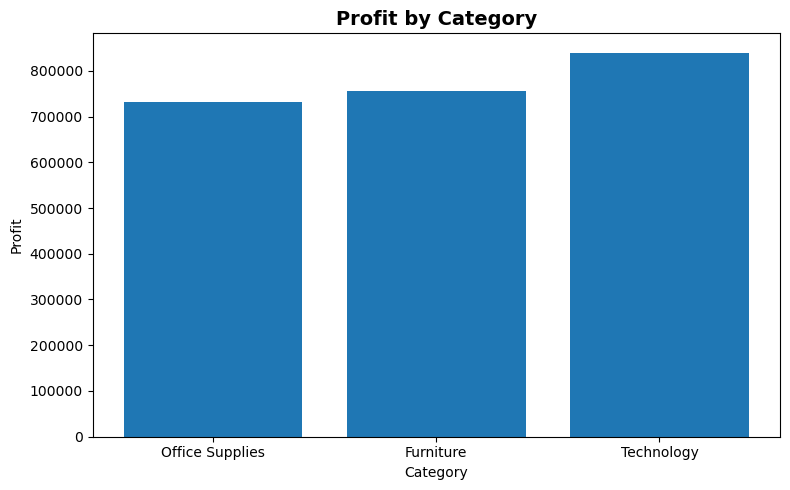

In [49]:
#Profit By Category    
import matplotlib.pyplot as plt
profit_category = df.groupby('Category')['Sales'].sum().sort_values()
plt.figure(figsize=(8,5))
plt.bar(profit_category.index, profit_category.values)
plt.title("Profit by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("Images/Profit_by_Category.png", dpi=300)
plt.show()                            


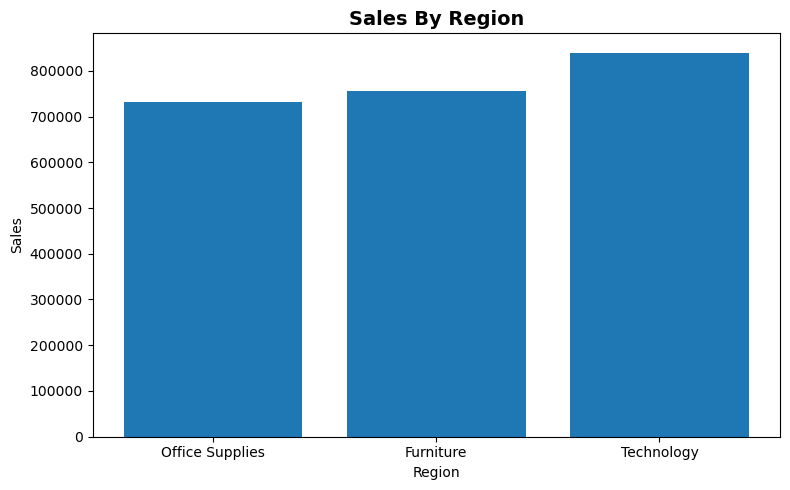

In [51]:
#Sales by region
import matplotlib.pyplot as plt
region_Sales = df.groupby('Region')['Sales'].sum().sort_values()
plt.figure(figsize=(8,5))
plt.bar(sales_category.index,sales_category.values)
plt.title('Sales By Region',fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.tight_layout()
plt.savefig("Images/Sales_By_Region.png",dpi=300)
plt.show()

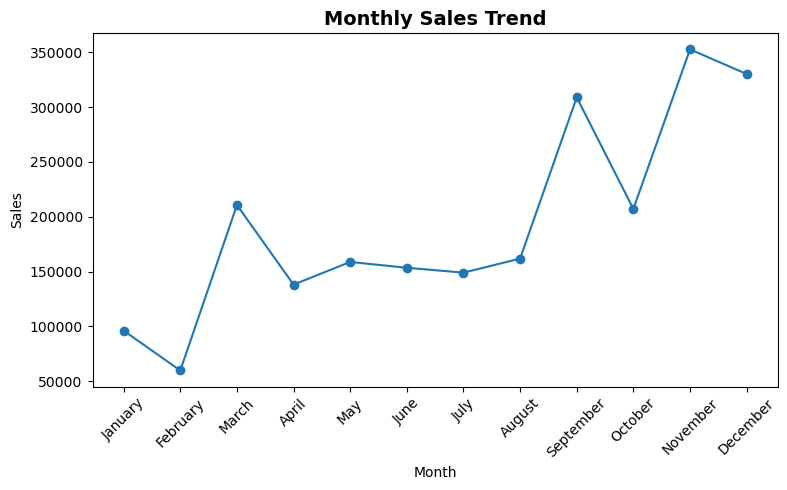

In [53]:
#Monthly Sales Trend
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Order Month')['Sales'].sum()
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o')
plt.title("Monthly Sales Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("Images/Monthly_Sales_Trend.png", dpi=300)
plt.show()



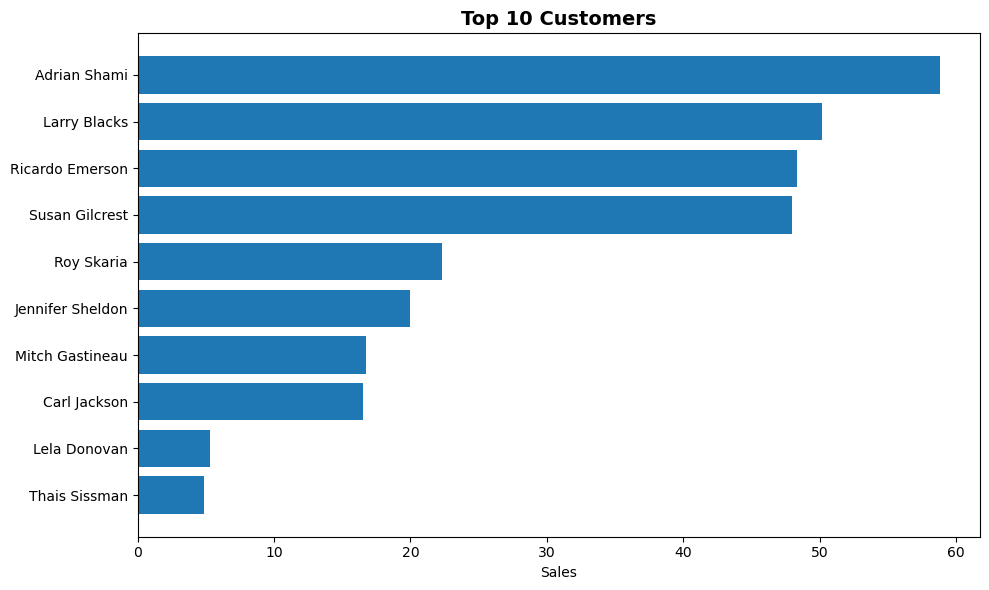

In [55]:
#Top 10 Customers
import matplotlib.pyplot as plt
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=True).head(10)
plt.figure(figsize=(10,6))
plt.barh(top_customers.index,top_customers.values)
plt.title("Top 10 Customers",fontsize=14,fontweight='bold')
plt.xlabel("Sales")

plt.tight_layout()
plt.savefig("Images/Top_10_Customers.png",dpi=300)
plt.show()


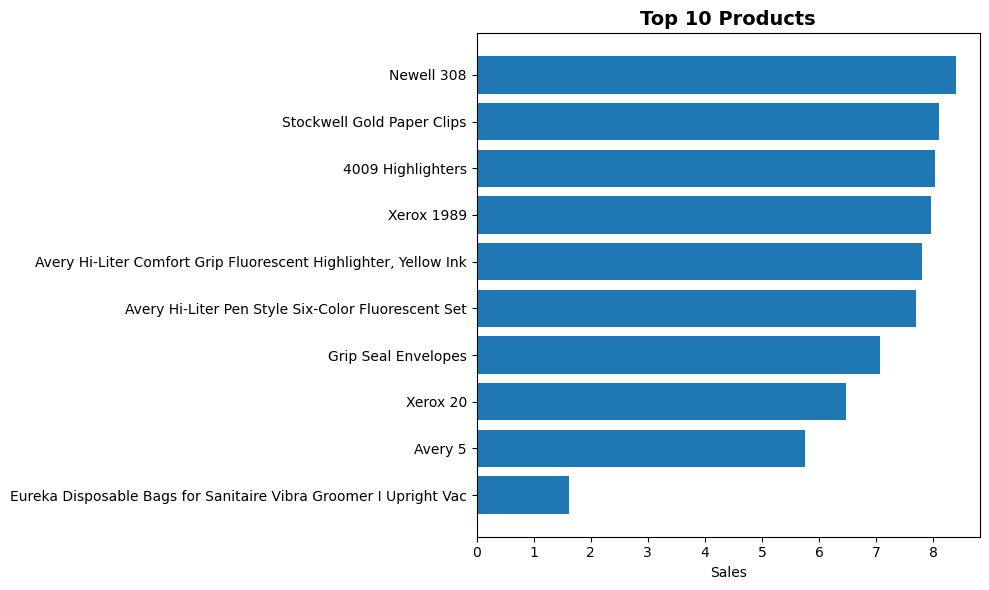

In [58]:
#Top 10 Products
import matplotlib.pyplot as plt
top_products = df.groupby("Product Name")['Sales'].sum().sort_values(ascending=True).head(10)
plt.figure(figsize=(10,6))
plt.barh(top_products.index,top_products.values)
plt.title("Top 10 Products",fontsize=14,fontweight='bold')
plt.xlabel('Sales')
plt.tight_layout()
plt.savefig("Images/Top_10_Products.png",dpi=300)
plt.show()

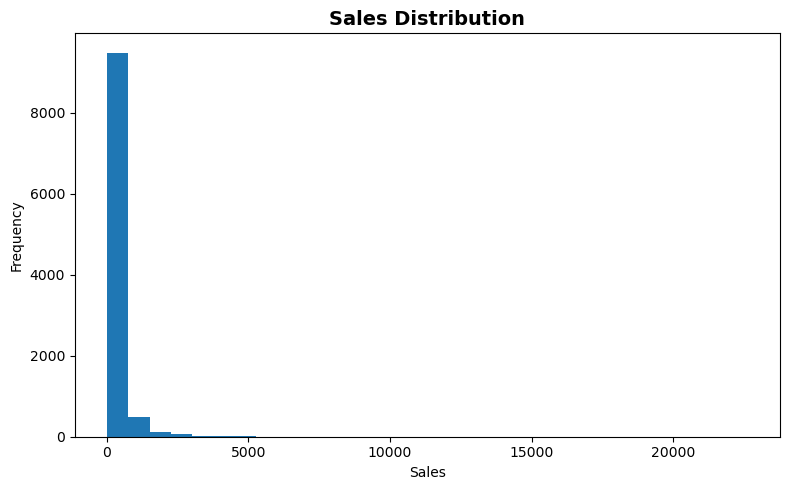

In [60]:
#Sales Distribution Using Histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)

plt.title("Sales Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("Images/Sales_Distribution.png", dpi=300)
plt.show()

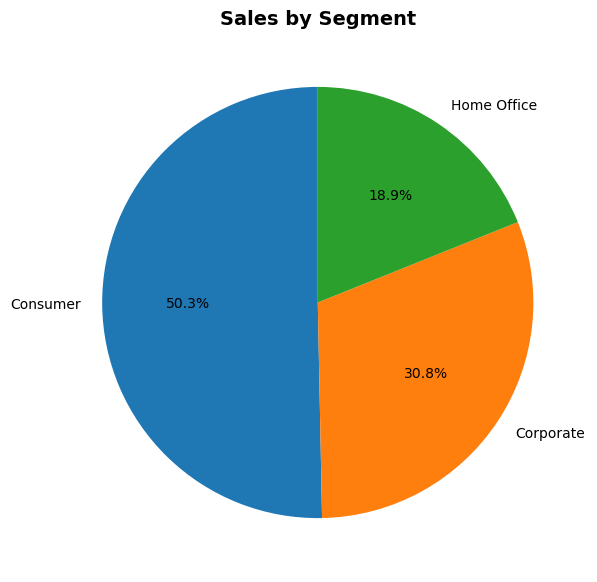

In [61]:
#Sales By segment Using PieChart
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(
    segment_sales.values,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales by Segment", fontsize=14, fontweight='bold')

plt.savefig("Images/Sales_by_Segment.png", dpi=300)
plt.show()

In [ ]:
# 📊 Business Insights

## Executive Summary

The Sample Superstore dataset was analyzed using Python (Pandas & Matplotlib) to evaluate sales performance, profitability, customer trends, and regional performance.

---

## 📈 Key Metrics

- **Total Sales:** ₹23,26,534.35
- **Total Profit:** ₹2,92,296.81
- **Total Orders:** 10,194
- **Average Order Value:** ₹228.23

---

## 🛍️ Category Insights

- **Technology** generated the highest sales of **₹8,39,893.28**.
- **Technology** also generated the highest profit of **₹1,46,543.38**.
- **Furniture** recorded the lowest profit (**₹19,729.99**), indicating lower profitability compared to other categories.

---

## 🌍 Regional Insights

- **West** region achieved the highest sales of **₹7,39,813.61**.
- **East** region ranked second with **₹6,91,828.17** in sales.
- **South** region recorded the lowest sales of **₹3,91,721.91**.
- **West** region also generated the highest profit (**₹1,10,798.82**).

---

## 👥 Customer Insights

- The **Consumer** segment generated the highest sales (**₹11.71 Lakhs**).
- **Sean Miller** was the highest revenue-generating customer with total sales of **₹25,043.05**.
- The Top 10 customers contributed significantly to overall revenue.

---

## 📌 Business Recommendations

- Increase marketing efforts for **Technology** products to maximize revenue.
- Improve the profitability of the **Furniture** category through pricing or cost optimization.
- Focus expansion and customer acquisition strategies in the **West** region.
- Develop loyalty programs for high-value customers such as **Sean Miller**.
- Analyze the **South** region to identify opportunities for improving sales performance.

---

# ✅ Conclusion

This project demonstrates end-to-end data analysis using Python, including:

- Data Cleaning
- Data Transformation
- Exploratory Data Analysis (EDA)
- Business Insights
- Data Visualization

The analysis provides actionable insights that can help businesses improve sales performance, profitability, and customer engagement.